# LSTM-AE on 3-channel Envelope Residual

**Kaggel Score: 0.867 Private score: 0.915**

Tests an LSTM autoencoder trained on the **baseline-corrected envelope signal** of the 3 level-shifted
channels (14, 21, 29) as a potential **third OR stream** for the hybrid champion (NB 11d).

### Why this direction

NB 12c already tested an LSTM *forecaster* on the same 3-channel env-residual (env3 env-residual
variant). That experiment found the forecaster's positives were a **strict subset** of the hybrid's,
adding no new information. An LSTM **autoencoder** is a different scoring approach - it learns to
reconstruct the envelope-residual signal and flags windows where reconstruction error is high, rather
than flagging forecast deviations. It may catch events the z-score env stream misses.

### Input preprocessing (shift mitigation)

Channels 14/21/29 undergo a sudden ~+5σ baseline shift between the training period and the Kaggle
test. Raw values are unusable as LSTM-AE inputs - training on the pre-shift baseline, the AE would
flag the entire post-shift period as anomalous (the shift-flood failure mode, §4 of results.md).

The envelope residual removes this shift:
```
env(t)  = rolling_min(raw, window=200)         # local envelope
envr(t) = env(t) − centered_MA(env, window=5000)  # subtract slow baseline
```
The centered MA absorbs the lock-step level shift; the residual `envr` is stationary across
train→test. This is identical to the env stream of the NB 11d hybrid.

### What determines success

The question is whether the LSTM-AE's reconstruction error on `envr` (3 channels, window 100)
provides **complementary** signal to the existing hybrid:
- If it catches events the hybrid misses AND adds no new FP_pred_events → SUBMIT as 3rd OR stream
- If its positives are a strict subset of the hybrid's → no value-add (same as NB 12c forecaster)
- If it adds more FP_pred_events than new TP_events → reject (§4.1 fusion failure mode)

## 0 - Setup

In [ ]:
import sys, time, pickle
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import warnings; warnings.filterwarnings('ignore')
import os; os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

from sentinel.params import (
    PROCESSED_DIR, MODELS_DIR,
    RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
)
from sentinel.ml_logic.scorer     import score_windows
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import event_f05, corrected_event_f05, row_precision_recall
from sentinel.ml_logic.data       import find_anomaly_segments
from sentinel.ml_logic.fusion     import fusion_diagnostics
from sentinel.ml_logic.viz        import plot_timeline, plot_event_analysis

tf.keras.utils.set_random_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

KAGGLE_DIR    = PROCESSED_DIR / 'kaggle'
SUBS_DIR      = PROJECT_ROOT / 'kaggle' / 'submissions'
SUBS_DIR.mkdir(parents=True, exist_ok=True)

FIT_SIZE      = 50_000
TRAIN_END     = 10_700_000
VAL_END       = 12_700_000

# Envelope params - identical to NB 11d hybrid champion
ENV_NAMES     = ['channel_14', 'channel_21', 'channel_29']
ENV_WINDOW    = 200
ENV_MA_WINDOW = 5_000
ENV_REF_PCT   = 99

print(f'TF {tf.__version__}   GPUs: {tf.config.list_physical_devices("GPU")}')
print(f'KAGGLE_DIR  : {KAGGLE_DIR}')
print(f'ENV channels: {ENV_NAMES}')
print(f'WINDOW_SIZE : {WINDOW_SIZE}   FIT_SIZE: {FIT_SIZE:,}')

TF 2.16.2   GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
KAGGLE_DIR  : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed/kaggle
ENV channels: ['channel_14', 'channel_21', 'channel_29']
WINDOW_SIZE : 100   FIT_SIZE: 50,000


## 1 - Load data and compute envelope residual

Applies the **identical** baseline-correction as the env stream of the NB 11d hybrid:
1. `rolling_min(env_w=200)` - local envelope tracks the signal floor.
2. `centered_MA(ma_w=5_000)` - smooth baseline that absorbs the lock-step level shift.
3. Residual = envelope − baseline (stationary across train→test).
4. Divide by nominal-train std (unit variance).

`ref_per_ch` (p99 of |residual| on train) is kept for z-score comparison plots but is
**not** used as LSTM-AE input - the AE sees the std-normalised residual directly.

In [2]:
y_train_full      = np.load(KAGGLE_DIR / 'y_train_full.npy')
train_scaled_full = np.load(KAGGLE_DIR / 'train_full_scaled.npy', mmap_mode='r')
test_scaled_full  = np.load(KAGGLE_DIR / 'test_scaled.npy')
test_ids          = np.load(KAGGLE_DIR / 'test_ids.npy')
y_train_row       = np.load(KAGGLE_DIR / 'y_train_row.npy')

_TARGET_CH = pd.read_csv(PROJECT_ROOT / 'data/raw/target_channels.csv')['target_channels'].tolist()
ENV_IDX    = np.array([_TARGET_CH.index(c) for c in ENV_NAMES], dtype=int)
N_ENV      = len(ENV_IDX)

print(f'train_scaled_full : {train_scaled_full.shape}  (mmap)')
print(f'test_scaled_full  : {test_scaled_full.shape}')
print(f'ENV channels      : {ENV_NAMES}  →  col idx {ENV_IDX.tolist()}')

train_scaled_full : (14728321, 58)  (mmap)
test_scaled_full  : (521280, 58)
ENV channels      : ['channel_14', 'channel_21', 'channel_29']  →  col idx [2, 9, 17]


In [ ]:
def compute_envr(arr2d, env_w, ma_w):
    """Baseline-corrected envelope residual. Shape: (n_rows, n_channels)."""
    out = np.empty_like(arr2d, dtype=np.float32)
    for j in range(arr2d.shape[1]):
        s   = pd.Series(arr2d[:, j])
        env = s.rolling(window=env_w, min_periods=1).min()
        ma  = env.rolling(window=ma_w, min_periods=1, center=True).mean()
        out[:, j] = (env - ma).values.astype(np.float32)
    return out

print('Computing envelope residual - train …')
t0 = time.time()
train_raw_env = np.ascontiguousarray(train_scaled_full[:, ENV_IDX], dtype=np.float32)
train_envr    = compute_envr(train_raw_env, ENV_WINDOW, ENV_MA_WINDOW)
print(f'  done in {time.time()-t0:.1f}s')

print('Computing envelope residual - test …')
test_raw_env = test_scaled_full[:, ENV_IDX].astype(np.float32)
test_envr    = compute_envr(test_raw_env, ENV_WINDOW, ENV_MA_WINDOW)

# Normalise by nominal-train std (identical to NB 11d)
nom_mask_row = y_train_row[:TRAIN_END] == 0
envr_std     = np.maximum(train_envr[:TRAIN_END][nom_mask_row].std(axis=0, keepdims=True), 1e-6)
train_envr   = (train_envr / envr_std).astype(np.float32)
test_envr    = (test_envr  / envr_std).astype(np.float32)

# p99 reference (same as NB 11d - used for z-score comparison only, not as AE input)
ref_per_ch = np.maximum(
    np.percentile(np.abs(train_envr[:TRAIN_END]), ENV_REF_PCT, axis=0), 1e-8
).astype(np.float32)

# Val / test splits
X_val  = np.ascontiguousarray(train_envr[TRAIN_END:VAL_END], dtype=np.float32)
y_val  = y_train_row[TRAIN_END:VAL_END].astype(np.int8)
X_test = np.ascontiguousarray(train_envr[VAL_END:], dtype=np.float32)
y_test = y_train_row[VAL_END:].astype(np.int8)

print(f'\nenvr_std (per ch)   : {envr_std.ravel().round(4).tolist()}')
print(f'ref_per_ch (p{ENV_REF_PCT})  : {ref_per_ch.round(3).tolist()}')
print(f'train_envr shape    : {train_envr.shape}   range [{train_envr.min():.3f}, {train_envr.max():.3f}]')
print(f'X_val               : {X_val.shape}   anom rows: {int(y_val.sum()):,}')
print(f'X_test              : {X_test.shape}   anom rows: {int(y_test.sum()):,}')

Computing envelope residual — train …
  done in 1.7s
Computing envelope residual — test …

envr_std (per ch)   : [0.011599999852478504, 0.01209999993443489, 0.010200000368058681]
ref_per_ch (p99)  : [6.769000053405762, 7.142000198364258, 5.263999938964844]
train_envr shape    : (14728321, 3)   range [-96.932, 54.080]
X_val               : (2000000, 3)   anom rows: 215,798
X_test              : (2028321, 3)   anom rows: 214,935


## 2 - Build LSTM-AE (3-channel input)

Much smaller than NB 12b's 58-channel architecture - 3 channels need far fewer parameters.

Architecture: Bi-LSTM(32) → LSTM(16) → LSTM(4) latent → RepeatVector → LSTM(16) → LSTM(32) → Dense(3)

In [4]:
LATENT_DIM = 4
HIDDEN_DIM = 32
DROPOUT    = 0.1

def build_lstm_ae_env(window_size, n_channels,
                      latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
    inputs = layers.Input(shape=(window_size, n_channels))

    # Encoder
    x      = layers.Bidirectional(
                 layers.LSTM(hidden_dim, return_sequences=True, dropout=dropout)
             )(inputs)
    x      = layers.LSTM(hidden_dim // 2, return_sequences=True, dropout=dropout)(x)
    latent = layers.LSTM(latent_dim, return_sequences=False, dropout=dropout)(x)

    # Bottleneck
    x = layers.RepeatVector(window_size)(latent)

    # Decoder
    x = layers.LSTM(hidden_dim // 2, return_sequences=True, dropout=dropout)(x)
    x = layers.LSTM(hidden_dim,      return_sequences=True, dropout=dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(n_channels))(x)

    model = Model(inputs, outputs, name='lstm_ae_env')
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_lstm_ae_env(WINDOW_SIZE, N_ENV)
model.summary()

Model: "lstm_ae_env"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 64)        │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 16)        │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 4)              │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 100, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 16)        │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 32)        │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 3)         │            99 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,451 (87.70 KB)

 Trainable params: 22,451 (87.70 KB)

 Non-trainable params: 0 (0.00 B)

## 3 - Fit on tail-50k nominal windows (train portion only)

Same recipe as NB 12b:
- Nominal windows with starting row < `TRAIN_END` (val/test stay disjoint).
- Take the **last 50 000** - recency bias keeps the fit regime close to val/test.
- No per-window Z-norm: the envelope residual is already baseline-corrected and shift-invariant.
  The AE learns to reconstruct the **shape** of the residual, not its magnitude.

In [5]:
nominal_mask = (y_train_full == 0)
cutoff_win   = TRAIN_END // WINDOW_SIZE
eligible     = np.flatnonzero(nominal_mask & (np.arange(len(y_train_full)) < cutoff_win))
fit_idx      = eligible[-FIT_SIZE:]

# Extract 3-channel env-residual windows from train_envr
row_starts  = fit_idx * WINDOW_SIZE
X_fit = np.stack(
    [train_envr[r:r + WINDOW_SIZE] for r in row_starts]
).astype(np.float32)                              # (FIT_SIZE, 100, 3)

print(f'Eligible nominal windows (pre-cutoff) : {len(eligible):,}')
print(f'Fitting on tail                        : {len(X_fit):,} windows')
print(f'X_fit shape                            : {X_fit.shape}  dtype={X_fit.dtype}')
print(f'X_fit per-ch mean / std                : {X_fit.mean(axis=(0,1)).round(4)} / {X_fit.std(axis=(0,1)).round(4)}')

EPOCHS     = 30
BATCH_SIZE = 128

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=4, min_delta=1e-4,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2,
        min_lr=1e-5, verbose=1,
    ),
]

t0 = time.time()
history = model.fit(
    X_fit, X_fit,
    validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=2, shuffle=True,
)
train_min = (time.time() - t0) / 60
n_ep      = len(history.history['loss'])
print(f'\nTrained in {train_min:.1f} min  ({n_ep} epochs)')

Eligible nominal windows (pre-cutoff) : 95,725
Fitting on tail                        : 50,000 windows
X_fit shape                            : (50000, 100, 3)  dtype=float32
X_fit per-ch mean / std                : [0.0217 0.0222 0.0524] / [1.0275 1.0089 1.1128]
Epoch 1/30
352/352 - 87s - 247ms/step - loss: 0.6819 - val_loss: 0.1261 - learning_rate: 0.0010
Epoch 2/30
352/352 - 76s - 215ms/step - loss: 0.3933 - val_loss: 0.1093 - learning_rate: 0.0010
Epoch 3/30
352/352 - 76s - 217ms/step - loss: 0.3326 - val_loss: 0.0970 - learning_rate: 0.0010
Epoch 4/30
352/352 - 76s - 215ms/step - loss: 0.2881 - val_loss: 0.0890 - learning_rate: 0.0010
Epoch 5/30
352/352 - 75s - 214ms/step - loss: 0.2792 - val_loss: 0.0839 - learning_rate: 0.0010
Epoch 6/30
352/352 - 75s - 214ms/step - loss: 0.2469 - val_loss: 0.0765 - learning_rate: 0.0010
Epoch 7/30
352/352 - 77s - 218ms/step - loss: 0.2426 - val_loss: 0.0762 - learning_rate: 0.0010
Epoch 8/30
352/352 - 76s - 215ms/step - loss: 0.2135 - val_loss:

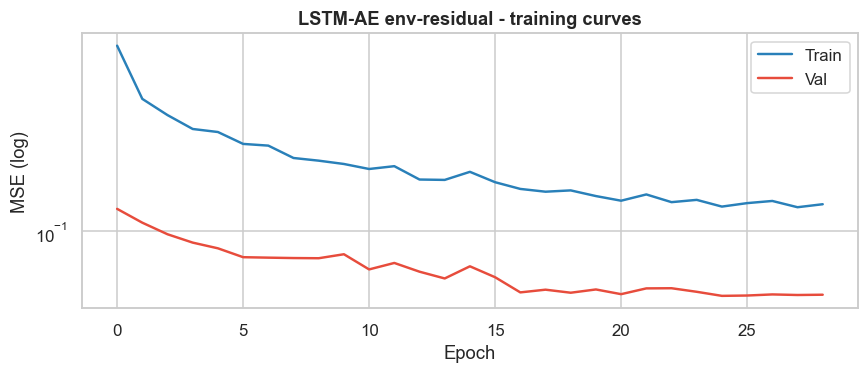

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(history.history['loss'],     lw=1.6, color=NOMINAL_COLOR, label='Train')
ax.plot(history.history['val_loss'], lw=1.6, color=ANOMALY_COLOR, label='Val')
ax.set_yscale('log'); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log)')
ax.set_title('LSTM-AE env-residual - training curves', fontweight='bold')
ax.legend(); fig.tight_layout(); plt.show()

## 4 - Score val + test_internal

`score_windows` reshapes rows into non-overlapping 100-row windows, runs the LSTM-AE,
and computes mean per-channel MSE per window (broadcast back to rows).
No Z-norm adapter needed - env-residual input is already shift-invariant.

scoring done in 33.3s

val  scores : [0.000367, 896.037720]
  nominal mean = 0.113708
  anomaly mean = 3.581562
test scores : [0.000367, 4613.259766]
  nominal mean = 1.015301
  anomaly mean = 18.306145


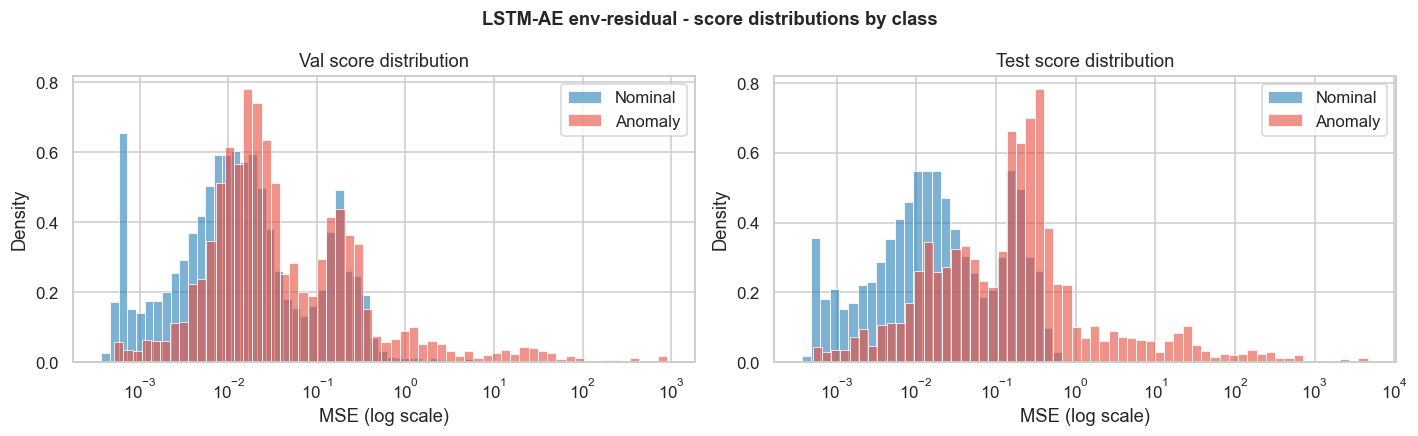

In [7]:
t0 = time.time()
val_scores  = score_windows(model, X_val,  win=WINDOW_SIZE, batch=256)
test_scores = score_windows(model, X_test, win=WINDOW_SIZE, batch=256)
print(f'scoring done in {time.time()-t0:.1f}s')

print(f'\nval  scores : [{val_scores.min():.6f}, {val_scores.max():.6f}]')
print(f'  nominal mean = {val_scores[y_val==0].mean():.6f}')
print(f'  anomaly mean = {val_scores[y_val==1].mean():.6f}')
print(f'test scores : [{test_scores.min():.6f}, {test_scores.max():.6f}]')
print(f'  nominal mean = {test_scores[y_test==0].mean():.6f}')
print(f'  anomaly mean = {test_scores[y_test==1].mean():.6f}')

# Score distribution plot (window-level)
n_win     = len(val_scores) // WINDOW_SIZE
win_label = y_val[:n_win * WINDOW_SIZE].reshape(n_win, WINDOW_SIZE).any(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, scores, y, title in [
    (axes[0], val_scores,  y_val,  'Val score distribution'),
    (axes[1], test_scores, y_test, 'Test score distribution'),
]:
    sns.histplot(scores[y==0], bins=60, ax=ax, label='Nominal', color=NOMINAL_COLOR, alpha=0.6, stat='density', log_scale=True)
    sns.histplot(scores[y==1], bins=60, ax=ax, label='Anomaly', color=ANOMALY_COLOR, alpha=0.6, stat='density', log_scale=True)
    ax.set_title(title); ax.legend(); ax.set_xlabel('MSE (log scale)')
fig.suptitle('LSTM-AE env-residual - score distributions by class', fontweight='bold')
fig.tight_layout(); plt.show()

## 5 - Threshold tuning and evaluation

Tune on **corrected_event_f05** (the Kaggle metric). Evaluate on test_internal.

In [8]:
tune       = tune_threshold(val_scores, y_val, metric_fn=corrected_event_f05)
threshold  = float(tune['threshold'])
val_esa    = float(tune['score'])
print(f'Val-tuned threshold  : {threshold:.6f}')
print(f'Val corrected F0.5   : {val_esa:.4f}')

y_pred_val  = (val_scores  > threshold).astype(np.int8)
y_pred_test = (test_scores > threshold).astype(np.int8)

def report(y_true, y_pred, name):
    ef  = event_f05(y_true, y_pred)
    esa = corrected_event_f05(y_true, y_pred)
    rw  = row_precision_recall(y_true, y_pred)
    n_t = int(ef['tp_events'] + ef['fn_events'])
    n_h = int(ef['tp_events'])
    print(f'\n--- {name} ---')
    print(f'  ESA F0.5 (corrected)  : {esa["f_score"]:.4f}')
    print(f'  Pr_ew (event prec)    : {esa["precision"]:.4f}')
    print(f'  TNR_t (row-level)     : {esa["tnr"]:.4f}')
    print(f'  Rec_e (event recall)  : {ef["recall"]:.4f}   events hit: {n_h}/{n_t}')
    print(f'  FP_pred_events        : {int(ef["fp_pred_events"])}')
    print(f'  flag rate             : {float(y_pred.mean()):.4f}')
    return y_pred

report(y_val,  y_pred_val,  'Val')
report(y_test, y_pred_test, 'Test (internal)')

Val-tuned threshold  : 8.268049
Val corrected F0.5   : 0.7571

--- Val ---
  ESA F0.5 (corrected)  : 0.7571
  Pr_ew (event prec)    : 0.9990
  TNR_t (row-level)     : 0.9990
  Rec_e (event recall)  : 0.3846   events hit: 10/26
  FP_pred_events        : 0
  flag rate             : 0.0046

--- Test (internal) ---
  ESA F0.5 (corrected)  : 0.6135
  Pr_ew (event prec)    : 0.8737
  TNR_t (row-level)     : 0.9986
  Rec_e (event recall)  : 0.2800   events hit: 7/25
  FP_pred_events        : 1
  flag rate             : 0.0094


array([0, 0, 0, ..., 0, 0, 0], dtype=int8)

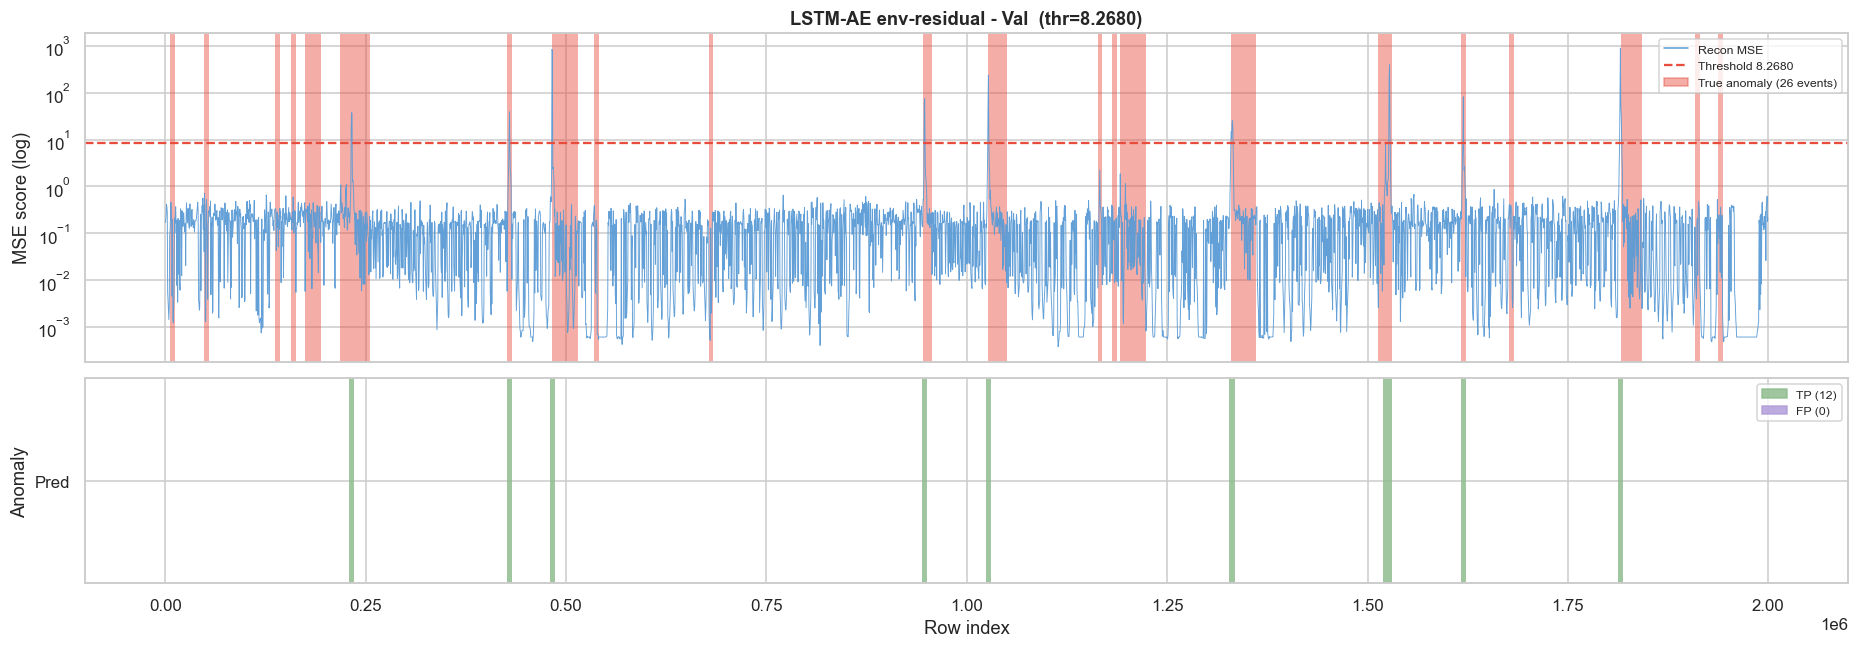

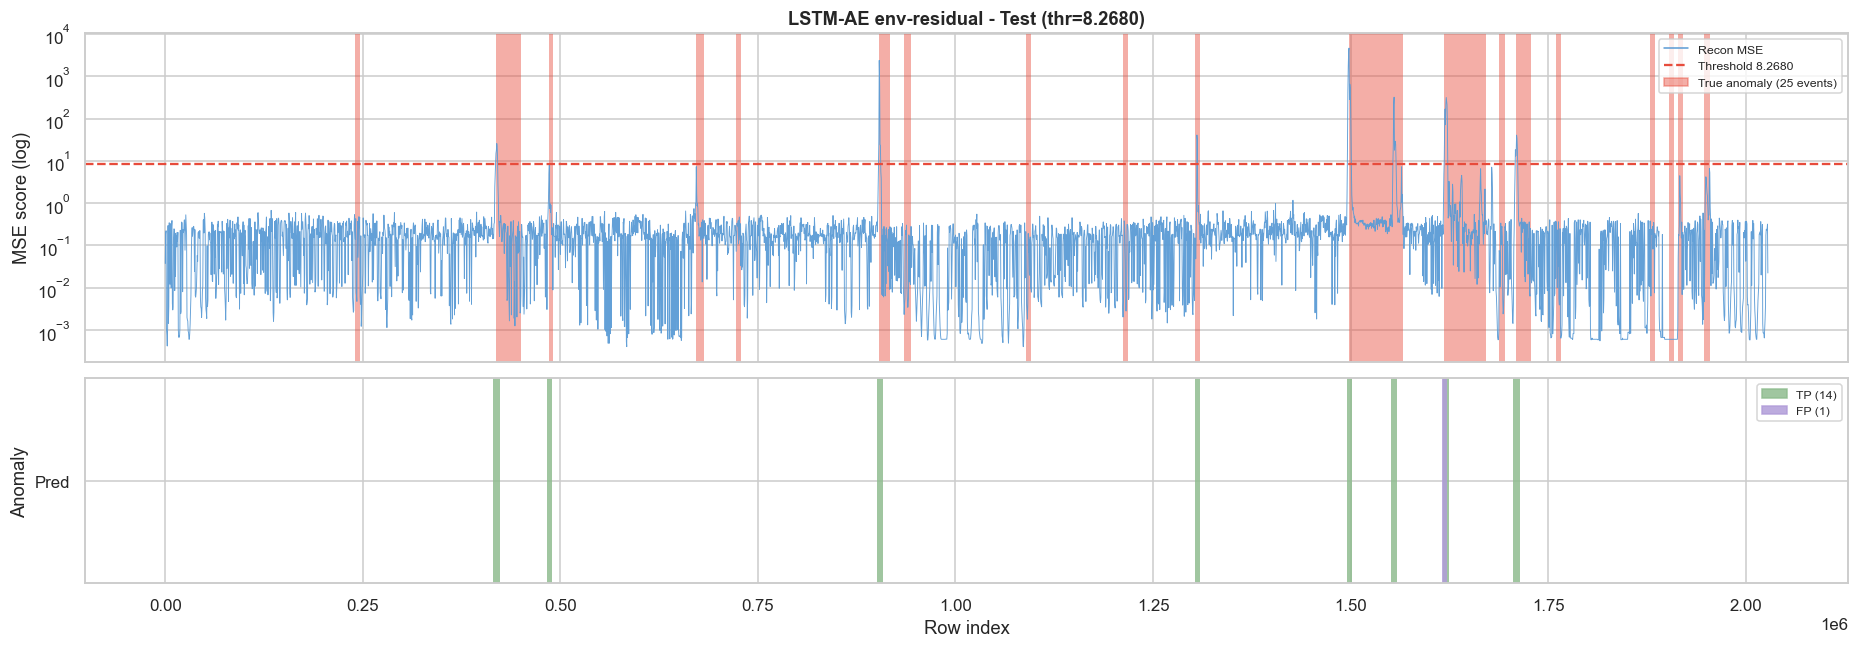

In [9]:
_ = plot_timeline(val_scores,  y_val,  threshold,
                  title=f'LSTM-AE env-residual - Val  (thr={threshold:.4f})', log_y=True)
plt.show()
_ = plot_timeline(test_scores, y_test, threshold,
                  title=f'LSTM-AE env-residual - Test (thr={threshold:.4f})', log_y=True)
plt.show()

Missed events:
  start     end  length
 242499  243978    1480
 672243  682244   10002
 722632  727323    4692
 937585  937616      32
 938221  938247      27
 939737  939759      23
 940375  940404      30
1092289 1092333      45
1215315 1215381      67
1690705 1690705       1
1690836 1692821    1986
1763508 1763538      31
1882095 1882116      22
1906275 1906299      25
1916825 1917361     537
1949666 1949668       3
1949681 1949683       3
1949804 1954252    4449


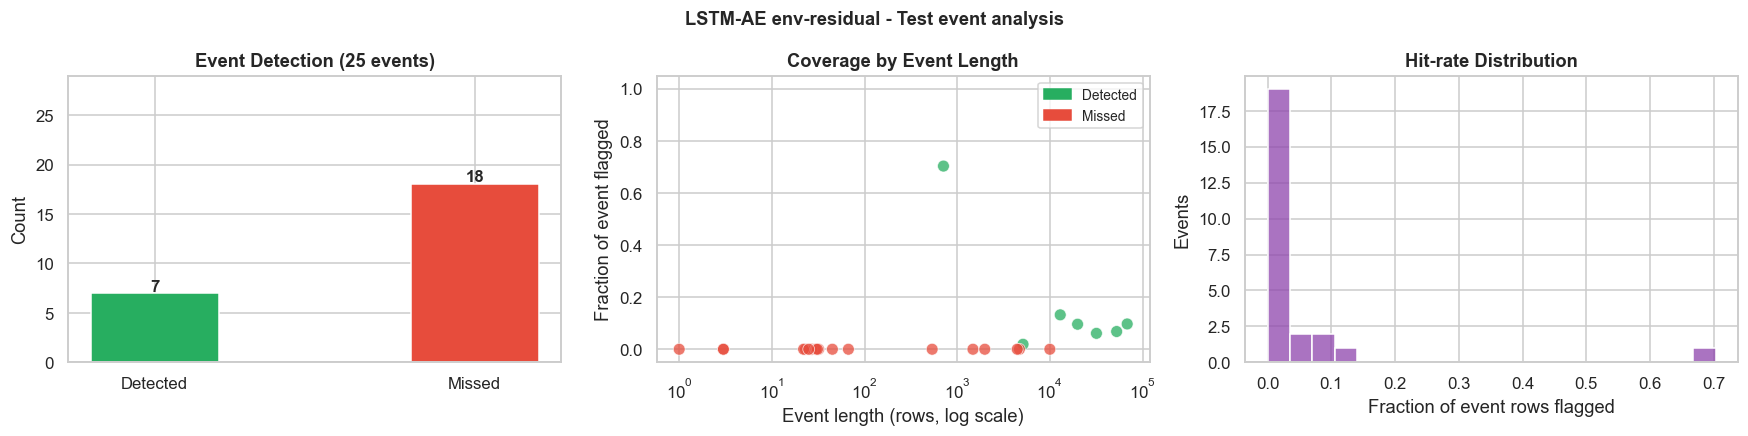

In [10]:
_ = plot_event_analysis(y_test, y_pred_test, title='LSTM-AE env-residual - Test event analysis')
plt.show()

## 6 - Fusion diagnostics against the champion hybrid

Before considering OR-fusion with the NB 11d hybrid, run `fusion_diagnostics`:
- **submit_strong / submit**: Δ TP_events > Δ FP_pred_events → complementary, safe to OR.
- **borderline**: Δ TP == Δ FP → marginal; check Kaggle flag-rate delta before submitting.
- **reject**: Δ FP_pred_events > Δ TP_events → would hurt the champion score.

The champion's test_internal labels are loaded from the pre-saved submission parquet
(which covers the Kaggle test rows, not internal test). We reconstruct the champion
internal-test predictions by re-running the champion threshold on the stored scores,
or load them from the saved NB 11d outputs.

In [13]:
# ── Reconstruct champion predictions on test_internal ────────────────────────
# NB 11d trains PCA(41-46) + zscore-env(14/21/29) and uses OR with independent
# thresholds: freq_thr=0.028049, env_thr=1.236990, k_env=2/3.
# We recompute from the scaled arrays already in memory.

from sklearn.decomposition import PCA as _PCA
from sentinel.ml_logic.scorer import score_windows as _sw

FREQ_IDX_CH = np.array([_TARGET_CH.index(f'channel_{i}') for i in range(41, 47)])
THR_FREQ    = 0.028049
THR_ENV     = 1.236990
K_ENV       = 2   # top-2/3 channels

def top_p_mean(arr2d, k):
    top = np.partition(arr2d, -k, axis=1)[:, -k:]
    return top.mean(axis=1)

print('Reconstructing champion freq scores …')
X_test_freq  = np.ascontiguousarray(train_scaled_full[VAL_END:, FREQ_IDX_CH], dtype=np.float32)

# Re-fit champion PCA (tail-50k nominal windows, same recipe)
nom_mask     = y_train_full == 0
cutoff_win   = TRAIN_END // WINDOW_SIZE
elig_idx     = np.flatnonzero(nom_mask & (np.arange(len(y_train_full)) < cutoff_win))[-FIT_SIZE:]
_rows        = (elig_idx[:, None] * WINDOW_SIZE + np.arange(WINDOW_SIZE)[None, :]).ravel()
X_fit_freq   = train_scaled_full[_rows, :][:, FREQ_IDX_CH].reshape(FIT_SIZE, -1).astype(np.float32)
pca_champ    = _PCA(n_components=0.95, random_state=RANDOM_STATE).fit(X_fit_freq)
del X_fit_freq

champ_freq_scores = _sw(pca_champ, X_test_freq, win=WINDOW_SIZE)

print('Reconstructing champion env scores …')
# X_test = train_envr[VAL_END:] already divided by envr_std — use it directly
# (test_envr is the Kaggle test array, different split)
z_test_env    = np.abs(X_test / ref_per_ch).astype(np.float32)  # (2028321, 3)
champ_env_sc  = top_p_mean(z_test_env, K_ENV)

y_champ_test  = ((champ_freq_scores > THR_FREQ) | (champ_env_sc > THR_ENV)).astype(np.int8)

esa_champ = corrected_event_f05(y_test, y_champ_test)
print(f'Champion test ESA F0.5 (reconstructed): {esa_champ["f_score"]:.4f}  '
      f'(expected 0.8216)')

# ── Fusion check ─────────────────────────────────────────────────────────────
print('\n── fusion_diagnostics (champion OR lstm-ae-env) ──')
diag = fusion_diagnostics(y_base=y_champ_test, y_new=y_pred_test, y_true=y_test)
d    = diag['delta']
print(f'Verdict        : {diag["verdict"]}')
print(f'Reason         : {diag["reason"]}')
print(f'ΔTP_events     : {d["TP_events"]}')
print(f'ΔFP_pred_events: {d["FP_pred_events"]}')
print(f'Δflag_rate     : {d["flag_rate"]:.4f} pp')

# OR-fused preview
y_or_test = np.maximum(y_champ_test, y_pred_test).astype(np.int8)
esa_or    = corrected_event_f05(y_test, y_or_test)
print(f'\nOR-fused ESA F0.5: {esa_or["f_score"]:.4f}  '
      f'(champion: {esa_champ["f_score"]:.4f}  '
      f'delta: {esa_or["f_score"]-esa_champ["f_score"]:+.4f})')

Reconstructing champion freq scores …
Reconstructing champion env scores …
Champion test ESA F0.5 (reconstructed): 0.8216  (expected 0.8216)

── fusion_diagnostics (champion OR lstm-ae-env) ──
Verdict        : submit
Reason         : gains exceed losses: +1 TP events vs +-1 FP segments.
ΔTP_events     : 1
ΔFP_pred_events: -1
Δflag_rate     : 0.0004 pp

OR-fused ESA F0.5: 0.8803  (champion: 0.8216  delta: +0.0587)


## 7 - Save model and Kaggle submission

Only uncomment and run after reviewing the fusion diagnostics above.
Submit only if verdict is `submit` or `submit_strong`.

In [ ]:
# ts = time.strftime('%Y%m%d_%H%M%S')
# model_path = MODELS_DIR / f'lstm_ae_env_nb12d_{ts}.keras'
# model.save(model_path)
# print(f'Model saved → {model_path}')

Model saved → /Users/helena.schulz.ext/code/alexfederolf/sentinel/models/lstm_ae_env_nb12d_20260501_134343.keras


In [ ]:
# # Score Kaggle test rows
# X_kaggle_env   = compute_envr(test_raw_env, ENV_WINDOW, ENV_MA_WINDOW) / envr_std
# kaggle_scores  = score_windows(model, X_kaggle_env.astype(np.float32), win=WINDOW_SIZE, batch=256)
# y_kaggle_lstm  = (kaggle_scores > threshold).astype(np.uint8)

# # Load champion Kaggle predictions
# champ_sub_path = sorted((PROJECT_ROOT / 'kaggle' / 'submissions').glob('pca_hybrid_envzscore_BEST.parquet'))[-1]
# champ_sub      = pd.read_parquet(champ_sub_path)
# y_kaggle_champ = champ_sub['is_anomaly'].values.astype(np.uint8)

# y_kaggle_or = np.maximum(y_kaggle_champ, y_kaggle_lstm).astype(np.uint8)

# print(f'Champion flag rate : {y_kaggle_champ.mean():.4%}')
# print(f'LSTM-AE flag rate  : {y_kaggle_lstm.mean():.4%}')
# print(f'OR flag rate       : {y_kaggle_or.mean():.4%}')

# ts  = time.strftime('%Y%m%d_%H%M%S')
# out = SUBS_DIR / f'lstm_ae_env_OR_hybrid_nb12d_{ts}.parquet'
# sub = pd.DataFrame({'id': test_ids, 'is_anomaly': y_kaggle_or})
# sub.to_parquet(out, index=False)
# print(f'Submission saved → {out}')

Champion flag rate : 1.5226%
LSTM-AE flag rate  : 0.5371%
OR flag rate       : 1.5500%
Submission saved → /Users/helena.schulz.ext/code/alexfederolf/sentinel/kaggle/submissions/lstm_ae_env_OR_hybrid_nb12d_20260501_134351.parquet
